# Using Optuna For Hypertuning and Optimizing the model

# Plan of Action
1. Number of Hidden layers
2. Neurons per layer
3. Number of epochs
4. Optimizer
5. Learning Rate
6. Batch Size
7. Dropout Layer (value of P)
8. Weight Decay(lambda)

## To increase accuracy:
* Expand Search Space
* increase no. of trials in study.optimize   

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset , DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Steps for GPU Training
## Check for GPU Availability

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
torch.manual_seed(42)

In [9]:
mnist_train=pd.read_csv("fashion-mnist_train.csv")
mnist_train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
mnist_train.shape

(60000, 785)

In [11]:
mnist_test=pd.read_csv("fashion-mnist_test.csv")
mnist_test.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
mnist_test.shape

(10000, 785)

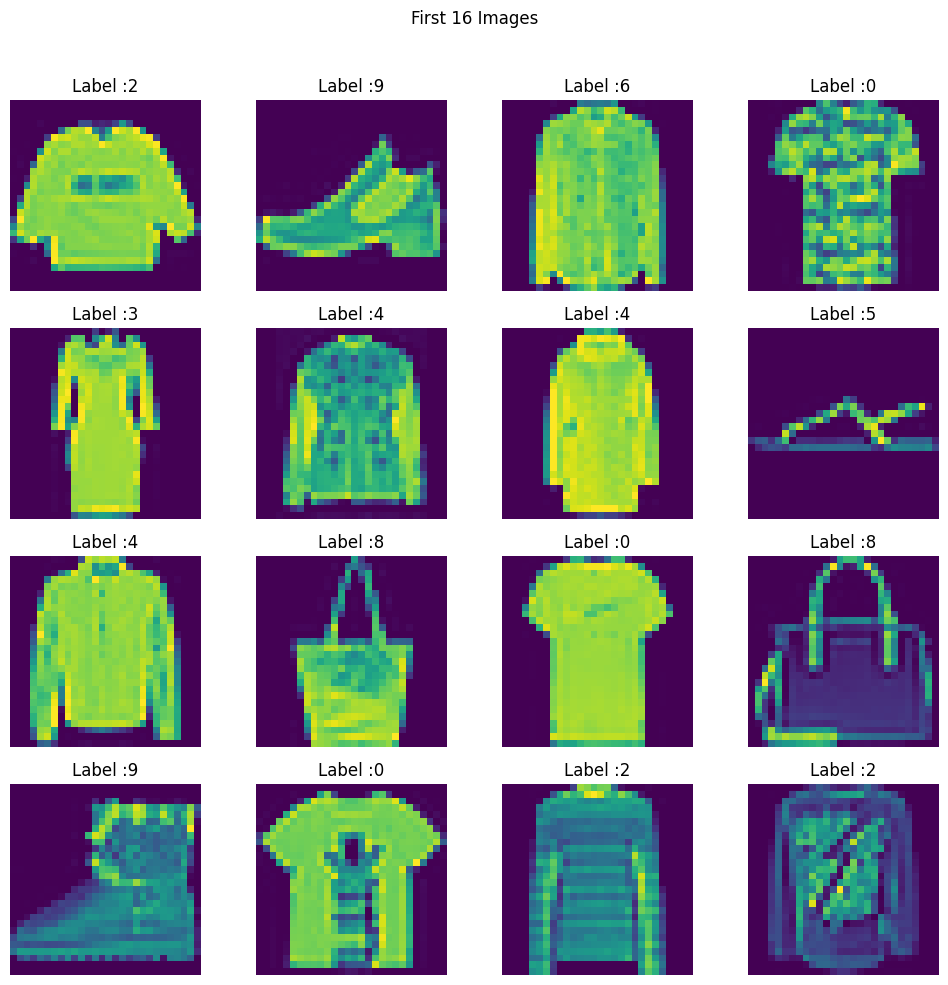

In [13]:
# Creating a 4x4 grid of images
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 Images")

# Plotting first 16 images
for i,ax in enumerate(axes.flat):
  img=mnist_train.iloc[i,1:].values.reshape(28,28) # reshape to 28 x 28 image
  ax.imshow(img) # Display in grayscale
  ax.axis('off')  #Remove axis for a cleaner look
  ax.set_title(f"Label :{mnist_train.iloc[i,0]}") #show label

plt.tight_layout(rect=[0,0,1,0.96]) # adjust layout to fit the title
plt.show()


In [14]:
x_train=mnist_train.iloc[:,1:].values
y_train=mnist_train.iloc[:,0].values
x_test=mnist_test.iloc[:,1:].values
y_test=mnist_test.iloc[:,0].values

In [15]:
# Scaling the features
x_train=x_train/255.0 # Dividing x_train with larget value
x_test=x_test/255.0

In [16]:
x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [17]:
x_train.shape

(60000, 784)

In [18]:
len(np.unique(y_train))

10

In [19]:
x_test.shape

(10000, 784)

In [20]:
# Create CustomDataset  Class
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features=torch.tensor(features,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self,index):

    return self.features[index], self.labels[index]


In [21]:
#Create Train & test Dataset Object
train_dataset=CustomDataset(x_train,y_train)
test_dataset=CustomDataset(x_test,y_test)


In [22]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0157, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.2431, 0.2392, 0.0824, 0.1137, 0.0902,
         0.2000, 0.5333, 0.2392, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [24]:
len(train_loader)

1875

In [26]:
from torch.nn.modules.linear import Linear
class MyNN(nn.Module):
  def __init__(self,number_hidden_layer, neurons_per_layer , input_dims, output_dims):

    super().__init__() # Calling parent class nn.Module
    layers=[]

    for i in range(number_hidden_layer):

      layers.append(nn.Linear(input_dims,neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(0.3))
      input_dims=neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer,output_dims))

    self.model=nn.Sequential(*layers) # *layers will automatically break list as Sequential doesnt accept list

  def forward(self,x):
    return self.model(x)


In [32]:
#objective Function
def objective(trial):

    # next hyperparameter values from the search space
    number_hidden_layer=trial.suggest_int("number_hidden_layers", 1,5)
    neurons_per_layer=trial.suggest_int("neurons_per_layer",8,128,step=8)
    epochs=trial.suggest_int("epochs",10 ,50, step=10)
    learning_rate=trial.suggest_float("learning_rate",1r-5,1e-1,log=True)
    Dropout_rate=trial.suggest_float("Dropout_rate",0.1,0.5,step=0.1)
    batch_size=trial.suggest_categorical("batch_size", [16,32,64,128])
    optimizer_name=trial.suggest_categorical("optimizer",['Adam','SGD','RMSprop'])
    weight_decay=trial.suggest_float("weight_decay",1e-5,1e-3,log=True)

    #creating train and test data loader
    train_loader=DataLoader(train_dataset, batch_size=batch_size,shuffle=True,pin_memory=True)
    test_loader=DataLoader(test_dataset,batch_size=batch_size, shuffle=False,pin_memory=True)

    # model init
    input_dims=x_train.shape[1]
    output_dims=len(np.unique(y_train))

    model=MyNN(number_hidden_layer , neurons_per_layer , input_dims, output_dims,Dropout_rate)
    model.to(device)

    # params init

    # optimizer selection
    criterion=nn.CrossEntropyLoss()
    #optimizer

    if optimizer_name=='Adam':
      optimizer =optim.Adam(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
    elif optimizer_name=='SGD':
      optimizer =optim.SGD(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
    else:
      optimizer =optim.RMSprop(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
    # training loop
    for epoch in range(epochs):

      total_epoch_loss = 0

      for batch_features, batch_labels in train_loader:
        #move data to GPU
        batch_features, batch_labels =batch_features.to(device) ,batch_labels.to(device) #modifying training loop by sending data to GPU
        # forward pass
        outputs = model(batch_features)

        # calculate loss
        loss = criterion(outputs, batch_labels)

        # back pass
        optimizer.zero_grad()
        loss.backward()

        # update grads
        optimizer.step()

    # evaluation
    model.eval()
    # evaluation code
    total=0
    correct=0
    with torch.no_grad(): # to avoid updation of parameters while predicting
      for batch_features , batch_labels in test_loader:

        batch_features, batch_labels =batch_features.to(device) ,batch_labels.to(device)

        outputs=model(batch_features)

        _,predicted=torch.max(outputs,1) # returns two values max value , indices in tensor form

        total=total+batch_features.shape[0]

        correct=correct + (predicted==batch_labels).sum().item() # add all the correct output

      accuracy=(correct/total)

    return accuracy

In [29]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.9 MB/s eta 0:00:00


In [30]:
import optuna
study=optuna.create_study(direction='maximize')

[I 2026-06-22 13:44:14,770] A new study created in memory with name: no-name-37cbc941-add1-49bf-9718-15955cef0ddc


In [33]:
study.optimize(objective , n_trials=10)

[I 2026-06-22 13:57:57,635] Trial 1 finished with value: 0.8734 and parameters: {'number_hidden_layers': 5, 'neurons_per_layer': 56}. Best is trial 1 with value: 0.8734.
[I 2026-06-22 14:07:31,962] Trial 2 finished with value: 0.8005 and parameters: {'number_hidden_layers': 3, 'neurons_per_layer': 16}. Best is trial 1 with value: 0.8734.
[I 2026-06-22 14:18:26,056] Trial 3 finished with value: 0.8733 and parameters: {'number_hidden_layers': 4, 'neurons_per_layer': 40}. Best is trial 1 with value: 0.8734.
[I 2026-06-22 14:30:37,141] Trial 4 finished with value: 0.8836 and parameters: {'number_hidden_layers': 5, 'neurons_per_layer': 64}. Best is trial 4 with value: 0.8836.
[I 2026-06-22 14:38:54,089] Trial 5 finished with value: 0.8887 and parameters: {'number_hidden_layers': 2, 'neurons_per_layer': 104}. Best is trial 5 with value: 0.8887.
[I 2026-06-22 14:49:45,909] Trial 6 finished with value: 0.8979 and parameters: {'number_hidden_layers': 4, 'neurons_per_layer': 128}. Best is trial 

In [34]:
study.best_value

0.8979

In [35]:
study.best_params

{'number_hidden_layers': 4, 'neurons_per_layer': 128}